In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_users.csv")
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [4]:
df.shape
df.columns

Index(['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type',
       'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login'],
      dtype='object')

In [5]:
df = df[['Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre']]
df.head()

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre
0,18,France,Premium,80.26,Drama
1,23,USA,Premium,321.75,Sci-Fi
2,60,UK,Basic,35.89,Comedy
3,44,USA,Premium,261.56,Documentary
4,68,USA,Standard,909.30,Drama


In [6]:
df = df.dropna()


In [7]:
df['Country'] = df['Country'].astype('category').cat.codes
df['Subscription_Type'] = df['Subscription_Type'].astype('category').cat.codes
df['Favorite_Genre'] = df['Favorite_Genre'].astype('category').cat.codes

In [8]:
X = df[['Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre']]

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df.head()

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,cluster
0,18,3,1,80.26,3,0
1,23,9,1,321.75,6,0
2,60,8,0,35.89,1,0
3,44,9,1,261.56,2,0
4,68,9,2,909.30,3,1


In [10]:
df.groupby('cluster').mean()

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre
cluster,,,,,
0,46.206457,4.569122,1.006554,168.257523,2.986406
1,46.682609,4.479952,0.984783,831.640336,2.978261
2,46.556420,4.519750,0.995048,499.878050,2.991746


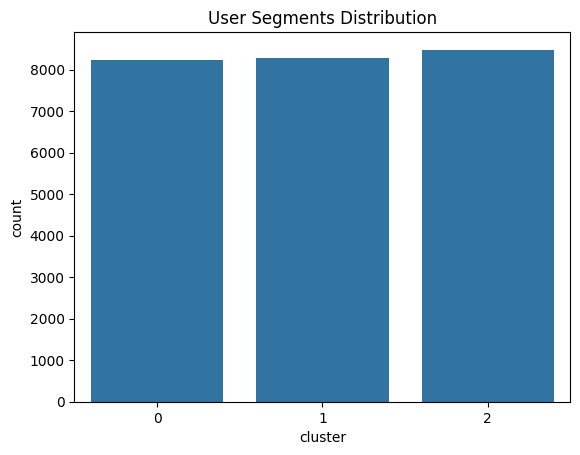

In [11]:
sns.countplot(x='cluster', data=df)
plt.title("User Segments Distribution")
plt.show()

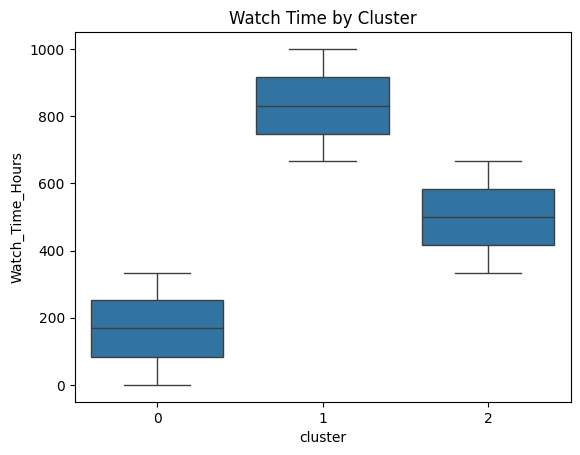

In [12]:
sns.boxplot(x='cluster', y='Watch_Time_Hours', data=df)
plt.title("Watch Time by Cluster")
plt.show()

In [21]:
df.to_csv("netflix_users_clustered.csv", index=False)


**Alternative implementation using PySpark**

## PySpark Implementation (Basic Data Processing)

In [14]:
!pip install pyspark

In [15]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("NetflixUserSegmentation").getOrCreate()

In [16]:
spark_df = spark.read.csv("netflix_users.csv", header=True, inferSchema=True)

spark_df.show(5)

+-------+--------------+---+-------+-----------------+----------------+--------------+----------+
|User_ID|          Name|Age|Country|Subscription_Type|Watch_Time_Hours|Favorite_Genre|Last_Login|
+-------+--------------+---+-------+-----------------+----------------+--------------+----------+
|      1|James Martinez| 18| France|          Premium|           80.26|         Drama|2024-05-12|
|      2|   John Miller| 23|    USA|          Premium|          321.75|        Sci-Fi|2025-02-05|
|      3|    Emma Davis| 60|     UK|            Basic|           35.89|        Comedy|2025-01-24|
|      4|   Emma Miller| 44|    USA|          Premium|          261.56|   Documentary|2024-03-25|
|      5|    Jane Smith| 68|    USA|         Standard|           909.3|         Drama|2025-01-14|
+-------+--------------+---+-------+-----------------+----------------+--------------+----------+
only showing top 5 rows


In [17]:
spark_df.groupBy("Subscription_Type").count().show()

+-----------------+-----+
|Subscription_Type|count|
+-----------------+-----+
|          Premium| 8402|
|            Basic| 8356|
|         Standard| 8242|
+-----------------+-----+



In [18]:
spark_df.groupBy("Favorite_Genre").count().show()

+--------------+-----+
|Favorite_Genre|count|
+--------------+-----+
|       Romance| 3572|
|         Drama| 3533|
|   Documentary| 3636|
|        Horror| 3654|
|        Comedy| 3561|
|        Action| 3589|
|        Sci-Fi| 3455|
+--------------+-----+



In [19]:
spark_df.groupBy("Country").count().show()

+---------+-----+
|  Country|count|
+---------+-----+
|  Germany| 2547|
|   France| 2473|
|    India| 2505|
|      USA| 2503|
|   Mexico| 2493|
|       UK| 2592|
|   Canada| 2490|
|   Brazil| 2503|
|    Japan| 2457|
|Australia| 2437|
+---------+-----+



In [20]:
spark_df.describe().show()

+-------+-----------------+--------------+------------------+---------+-----------------+------------------+--------------+
|summary|          User_ID|          Name|               Age|  Country|Subscription_Type|  Watch_Time_Hours|Favorite_Genre|
+-------+-----------------+--------------+------------------+---------+-----------------+------------------+--------------+
|  count|            25000|         25000|             25000|    25000|            25000|             25000|         25000|
|   mean|          12500.5|          NULL|          46.48288|     NULL|             NULL|500.46885799999865|          NULL|
| stddev|7217.022700994273|          NULL|19.594861194941107|     NULL|             NULL| 286.3818152485371|          NULL|
|    min|                1|    Alex Brown|                13|Australia|            Basic|              0.12|        Action|
|    max|            25000|Sarah Williams|                80|      USA|         Standard|            999.99|        Sci-Fi|
+-------